# SPACE CONNECT: OrbitGuard
**Solução tecnológica para monitoramento de desastres via satélite.**

**Problema:** Eventos climáticos extremos, como furacões, exigem respostas rápidas. A análise manual de imagens de satélite e aéreas é lenta e ineficiente.
**Visão da Solução:** Um MVP de Visão Computacional que automatiza a detecção e o cálculo da área afetada por desastres utilizando processamento de imagens.
**Valor de Negócio:** Redução do tempo de resposta de equipes de resgate e precisão no mapeamento do impacto ambiental (Alinhado aos ODS 11 e 13 da ONU).

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

%matplotlib inline

### Metodologia Aplicada
Empregamos o pipeline clássico de processamento digital de imagens:
1. **Filtro Gaussiano:** Suavização para remoção de ruído do terreno.
2. **Espaço HSV:** Segmentação de cores para isolar a área de impacto (enchentes ou destroços de casas).
3. **Morfologia Matemática:** Fechamento para unificar a máscara binária e remover falsos positivos.
4. **Extração de Características:** Uso de Contornos e Momentos para calcular a área em pixels e extrair a métrica final.

In [ ]:
def processar_imagem_satelite(nome_arquivo, limite_inferior_hsv, limite_superior_hsv, titulo_desastre):
    caminho = os.path.join("Images", nome_arquivo)
    img = cv2.imread(caminho)
    
    if img is None:
        print(f"Erro ao carregar: {caminho}")
        return
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_blur = cv2.GaussianBlur(img_rgb, (5, 5), 0)
    img_hsv = cv2.cvtColor(img_blur, cv2.COLOR_RGB2HSV)
    mascara = cv2.inRange(img_hsv, limite_inferior_hsv, limite_superior_hsv)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    mascara_limpa = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel)
    contornos, _ = cv2.findContours(mascara_limpa, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    area_total_pixels = img.shape[0] * img.shape[1]
    area_afetada_pixels = 0
    img_resultado = img_rgb.copy()
    
    for cnt in contornos:
        area = cv2.contourArea(cnt)
        if area > 1000:
            area_afetada_pixels += area
            cv2.drawContours(img_resultado, [cnt], -1, (255, 0, 0), 3)
            
    porcentagem_afetada = (area_afetada_pixels / area_total_pixels) * 100
    
    fig = plt.figure(figsize=(18, 5))
    fig.suptitle(f"Análise de Desastre: {titulo_desastre}", fontsize=16)

    plt.subplot(1, 4, 1)
    plt.imshow(img_rgb)
    plt.title("Imagem Original")
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(mascara_limpa, cmap='gray')
    plt.title("Máscara do Evento")
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(img_resultado)
    plt.title(f"Área Detectada ({porcentagem_afetada:.2f}%)")
    plt.axis('off')

    plt.subplot(1, 4, 4)
    labels = ['Área Afetada', 'Área Intacta']
    sizes = [porcentagem_afetada, 100 - porcentagem_afetada]
    colors = ['#ff9999','#66b3ff']
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    plt.title('Impacto Global')
    
    plt.tight_layout()
    plt.show()

    print(f"--- Relatório: {titulo_desastre} ---")
    print(f"Área total analisada: {area_total_pixels} pixels")
    print(f"Área crítica detectada: {area_afetada_pixels} pixels")
    print(f"Percentual de degradação: {porcentagem_afetada:.2f}%\n")

### Análise e Resultados - Impacto do Furacão
Abaixo, instanciamos o algoritmo para analisar os danos causados por um furacão. Ajustamos o espaço HSV para classificar dois tipos de danos distintos: enchentes causadas por chuvas intensas e estruturas residenciais destruídas pelos ventos. Do ponto de vista de Business Intelligence, isso permite direcionar recursos de resgate específicos (barcos vs. maquinário pesado) para cada setor.

>>> INICIANDO ANÁLISE DE ENCHENTES (ÁGUAS TURVAS/LAMA) <<<


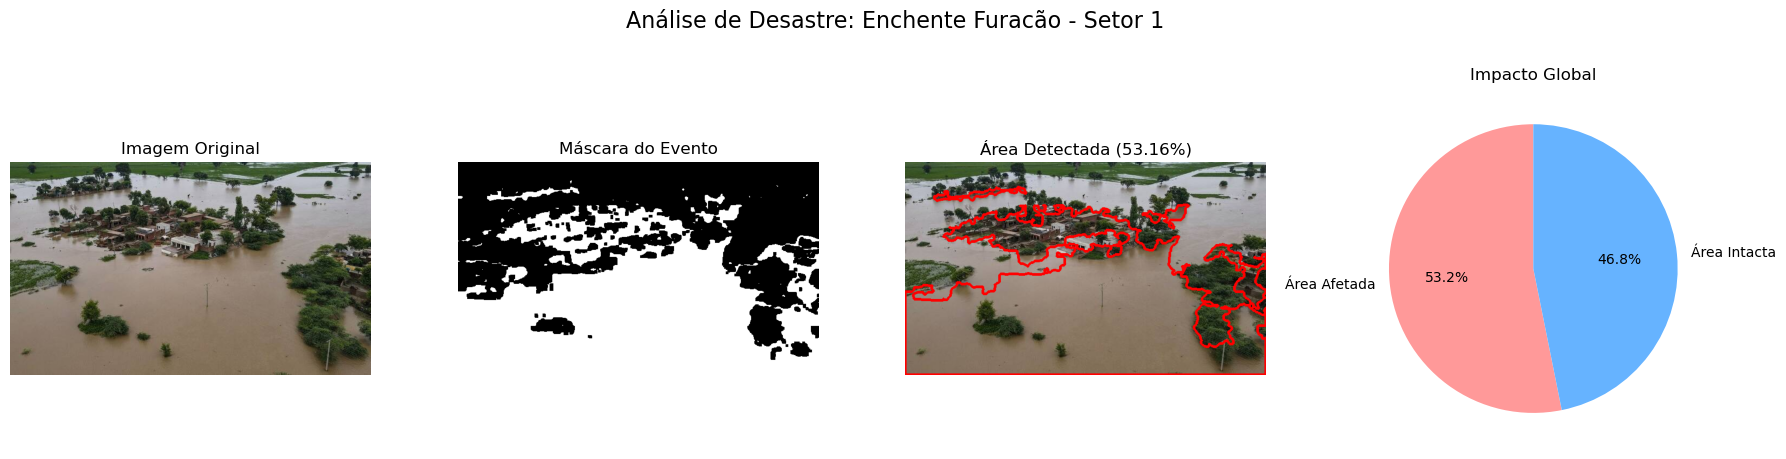

--- Relatório: Enchente Furacão - Setor 1 ---
Área total analisada: 264650 pixels
Área crítica detectada: 140693.0 pixels
Percentual de degradação: 53.16%



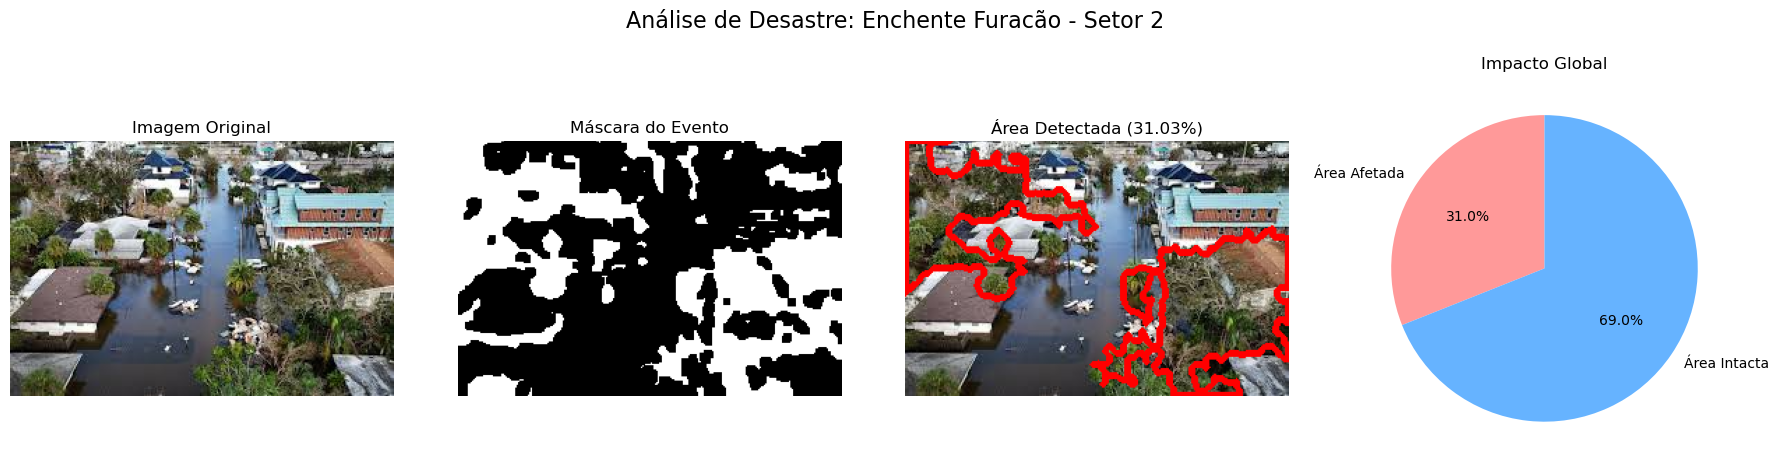

--- Relatório: Enchente Furacão - Setor 2 ---
Área total analisada: 50325 pixels
Área crítica detectada: 15615.0 pixels
Percentual de degradação: 31.03%



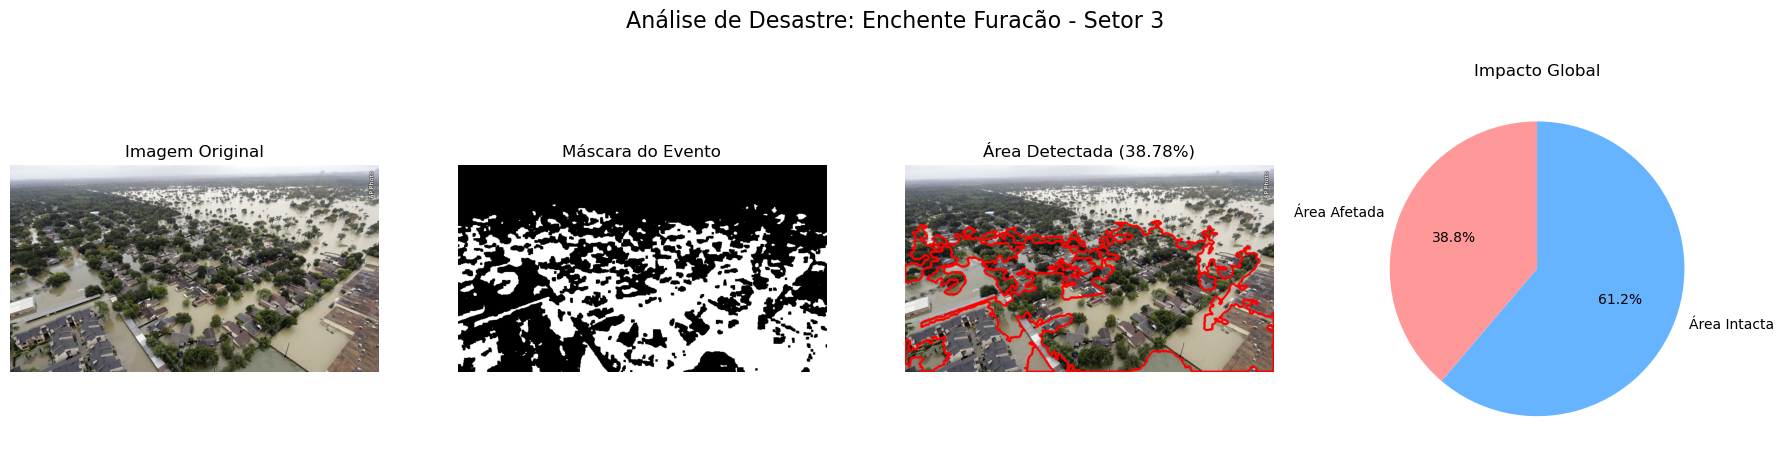

--- Relatório: Enchente Furacão - Setor 3 ---
Área total analisada: 348641 pixels
Área crítica detectada: 135218.5 pixels
Percentual de degradação: 38.78%


>>> INICIANDO ANÁLISE DE DESTROÇOS (ESTRUTURAS/CASAS) <<<


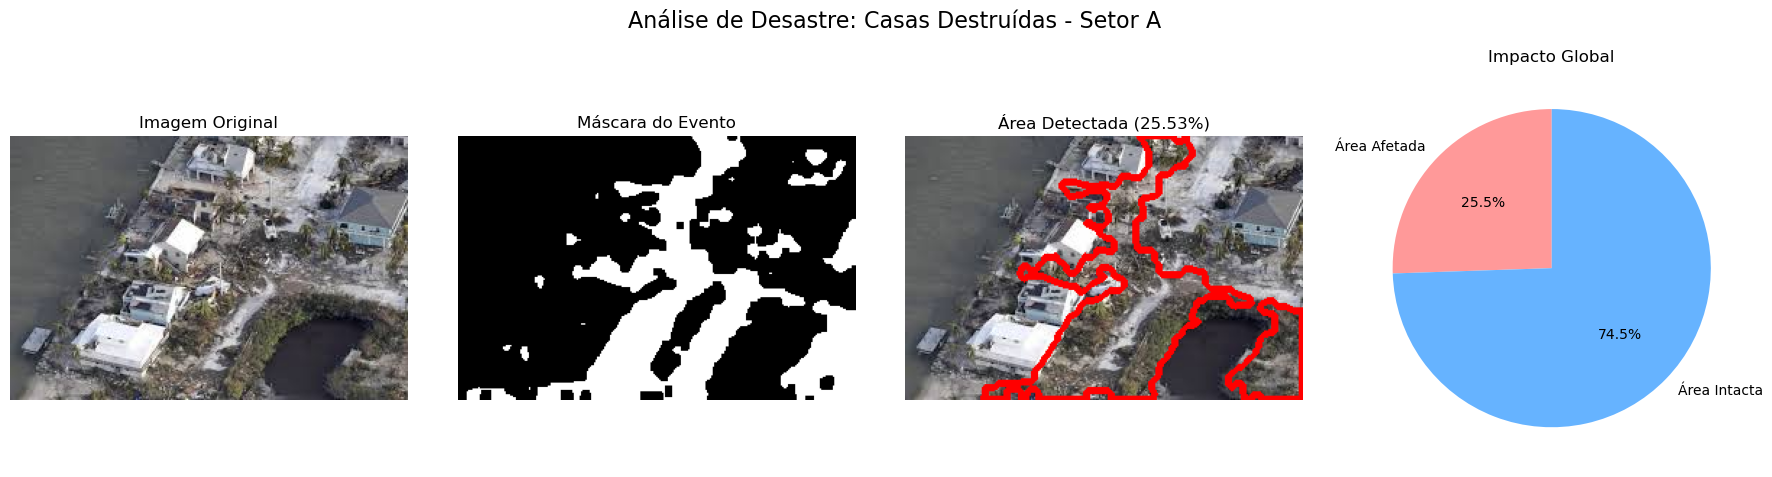

--- Relatório: Casas Destruídas - Setor A ---
Área total analisada: 50325 pixels
Área crítica detectada: 12849.5 pixels
Percentual de degradação: 25.53%



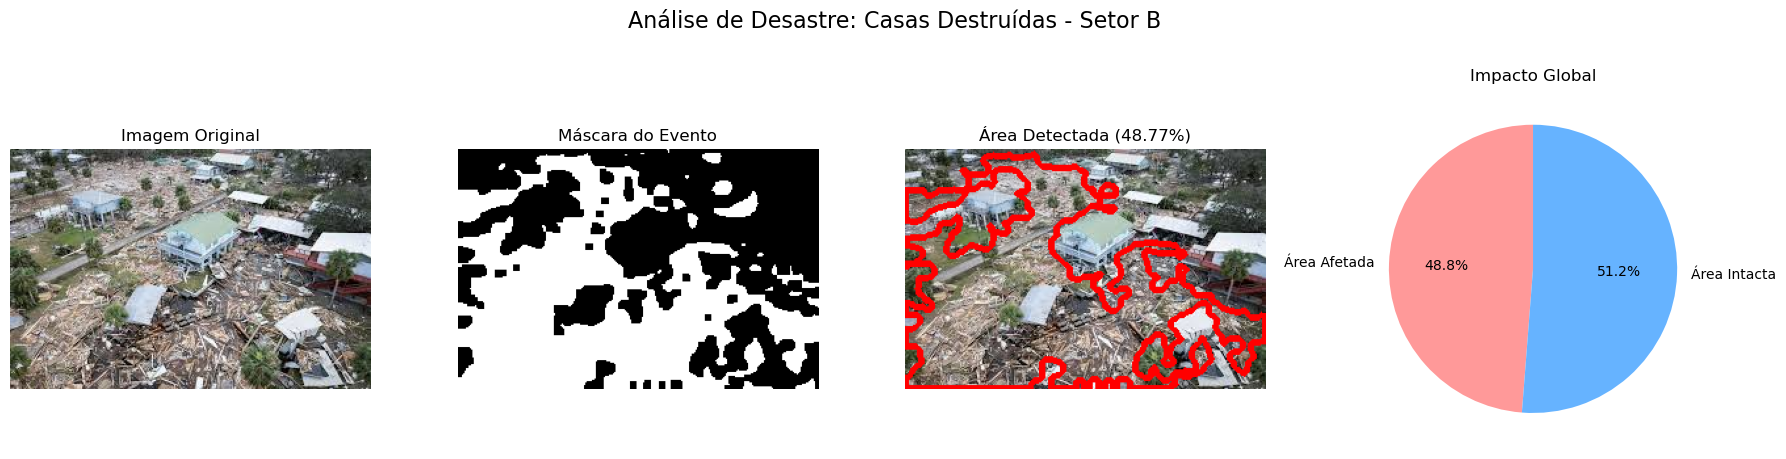

--- Relatório: Casas Destruídas - Setor B ---
Área total analisada: 50325 pixels
Área crítica detectada: 24543.0 pixels
Percentual de degradação: 48.77%



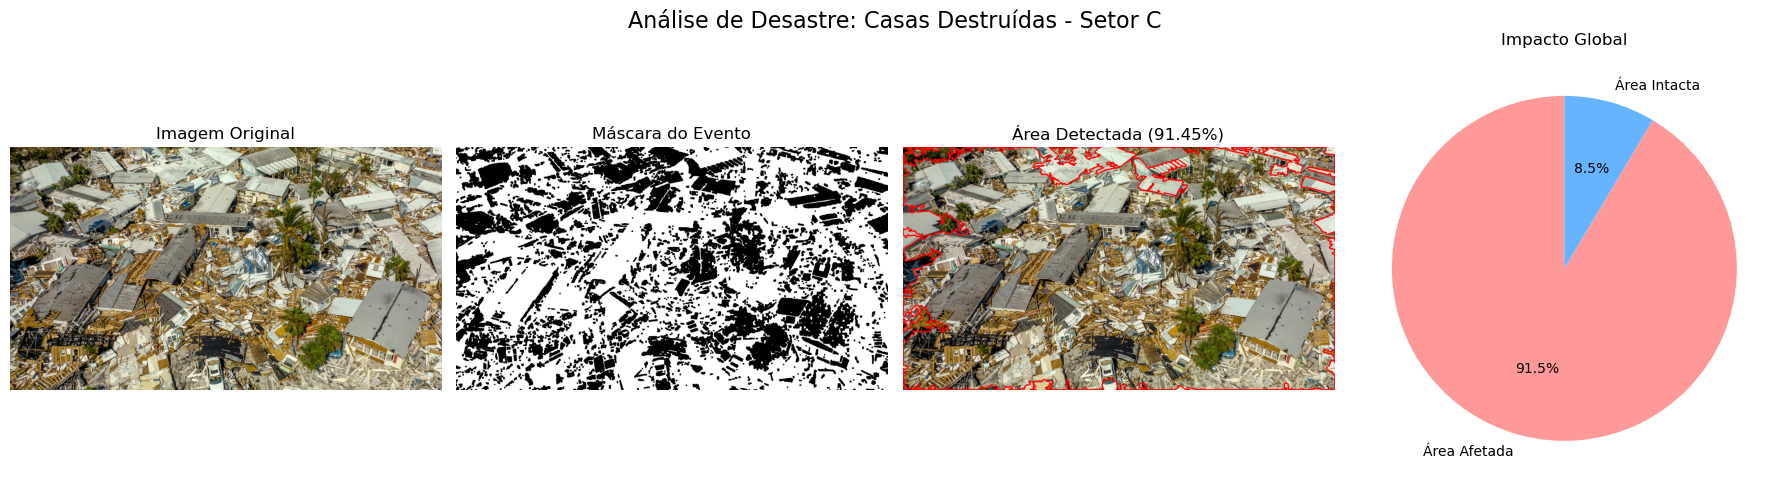

--- Relatório: Casas Destruídas - Setor C ---
Área total analisada: 1440000 pixels
Área crítica detectada: 1316880.5 pixels
Percentual de degradação: 91.45%



In [12]:
limite_inferior_enchente = np.array([10, 40, 40])
limite_superior_enchente = np.array([40, 255, 255])

limite_inferior_destrocos = np.array([0, 10, 50])
limite_superior_destrocos = np.array([35, 150, 200])

print("="*60)
print(">>> INICIANDO ANÁLISE DE ENCHENTES (ÁGUAS TURVAS/LAMA) <<<")
print("="*60)
processar_imagem_satelite("Desastre 1.jpg", limite_inferior_enchente, limite_superior_enchente, "Enchente Furacão - Setor 1")
processar_imagem_satelite("Desastre 2.jpg", limite_inferior_enchente, limite_superior_enchente, "Enchente Furacão - Setor 2")
processar_imagem_satelite("Desastre 5.jpg", limite_inferior_enchente, limite_superior_enchente, "Enchente Furacão - Setor 3")

print("\n" + "="*60)
print(">>> INICIANDO ANÁLISE DE DESTROÇOS (ESTRUTURAS/CASAS) <<<")
print("="*60)
processar_imagem_satelite("Desastre 3.jpg", limite_inferior_destrocos, limite_superior_destrocos, "Casas Destruídas - Setor A")
processar_imagem_satelite("Desastre 4.jpg", limite_inferior_destrocos, limite_superior_destrocos, "Casas Destruídas - Setor B")
processar_imagem_satelite("Desastre 6.jpg", limite_inferior_destrocos, limite_superior_destrocos, "Casas Destruídas - Setor C")